# 13 — Correlation Dynamics: When Diversification Assumptions Go Stale

**Lesson:** Correlations change, and the change matters more than the level. The correlation you estimated from 252 days of history may not be the correlation you experience tomorrow — and when it shifts, your VaR number is living on borrowed time.

This notebook answers: *how fast does the SPY/BND correlation actually change, how much does the estimate lag reality, and what does that lag mean for the VaR numbers you report?*

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKERS = ["SPY", "BND"]
WEIGHTS = [0.60, 0.40]
START_DATE = "2018-01-01"
END_DATE = None
CONFIDENCE = 0.95
VAR_WINDOW = 252
CORR_WINDOW_SLOW = 252
CORR_WINDOW_FAST = 60

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.historical_var import historical_var
from src.rolling import rolling_var
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
# Download and prepare data (same as Notebook 12)
prices = {}
returns = {}
for ticker in TICKERS:
    prices[ticker] = download_close_prices(ticker, start=START_DATE, end=END_DATE)
    returns[ticker] = prepare_returns(prices[ticker])

# Align dates
aligned = pd.DataFrame({
    TICKERS[0]: returns[TICKERS[0]],
    TICKERS[1]: returns[TICKERS[1]],
}).dropna()

# Portfolio returns
portfolio_returns = (WEIGHTS[0] * aligned[TICKERS[0]] +
                     WEIGHTS[1] * aligned[TICKERS[1]])

print(f"Data: {len(aligned)} days, {aligned.index[0].date()} to {aligned.index[-1].date()}")

Prepared 2149 daily returns (2018-01-03 to 2026-07-23) from 2150 price observations.


Prepared 2149 daily returns (2018-01-03 to 2026-07-23) from 2150 price observations.
Data: 2149 days, 2018-01-03 to 2026-07-23


---

## Part A: Rolling correlation — fast vs slow

Same idea as the multi-window VaR approach: run two windows and watch the divergence. The 252-day correlation is the "structural" estimate — slow, stable, used in long-run assumptions. The 60-day correlation is the "tactical" estimate — faster to react, noisier, used for detecting shifts.

In [4]:
# Rolling correlations
spy = aligned[TICKERS[0]]
bnd = aligned[TICKERS[1]]

corr_252 = spy.rolling(window=CORR_WINDOW_SLOW).corr(bnd)
corr_60 = spy.rolling(window=CORR_WINDOW_FAST).corr(bnd)

# Drop NaN warm-up
corr_252 = corr_252.dropna()
corr_60 = corr_60.dropna()

print(f"252-day correlation:")
print(f"  Mean:   {corr_252.mean():.3f}")
print(f"  Min:    {corr_252.min():.3f}  ({corr_252.idxmin().date()})")
print(f"  Max:    {corr_252.max():.3f}  ({corr_252.idxmax().date()})")
print(f"  Latest: {corr_252.iloc[-1]:.3f}")
print(f"\n60-day correlation:")
print(f"  Mean:   {corr_60.mean():.3f}")
print(f"  Min:    {corr_60.min():.3f}  ({corr_60.idxmin().date()})")
print(f"  Max:    {corr_60.max():.3f}  ({corr_60.idxmax().date()})")
print(f"  Latest: {corr_60.iloc[-1]:.3f}")

252-day correlation:
  Mean:   0.101
  Min:    -0.410  (2020-02-24)
  Max:    0.386  (2020-03-13)
  Latest: 0.299

60-day correlation:
  Mean:   0.053
  Min:    -0.550  (2020-02-24)
  Max:    0.705  (2026-06-05)
  Latest: 0.555


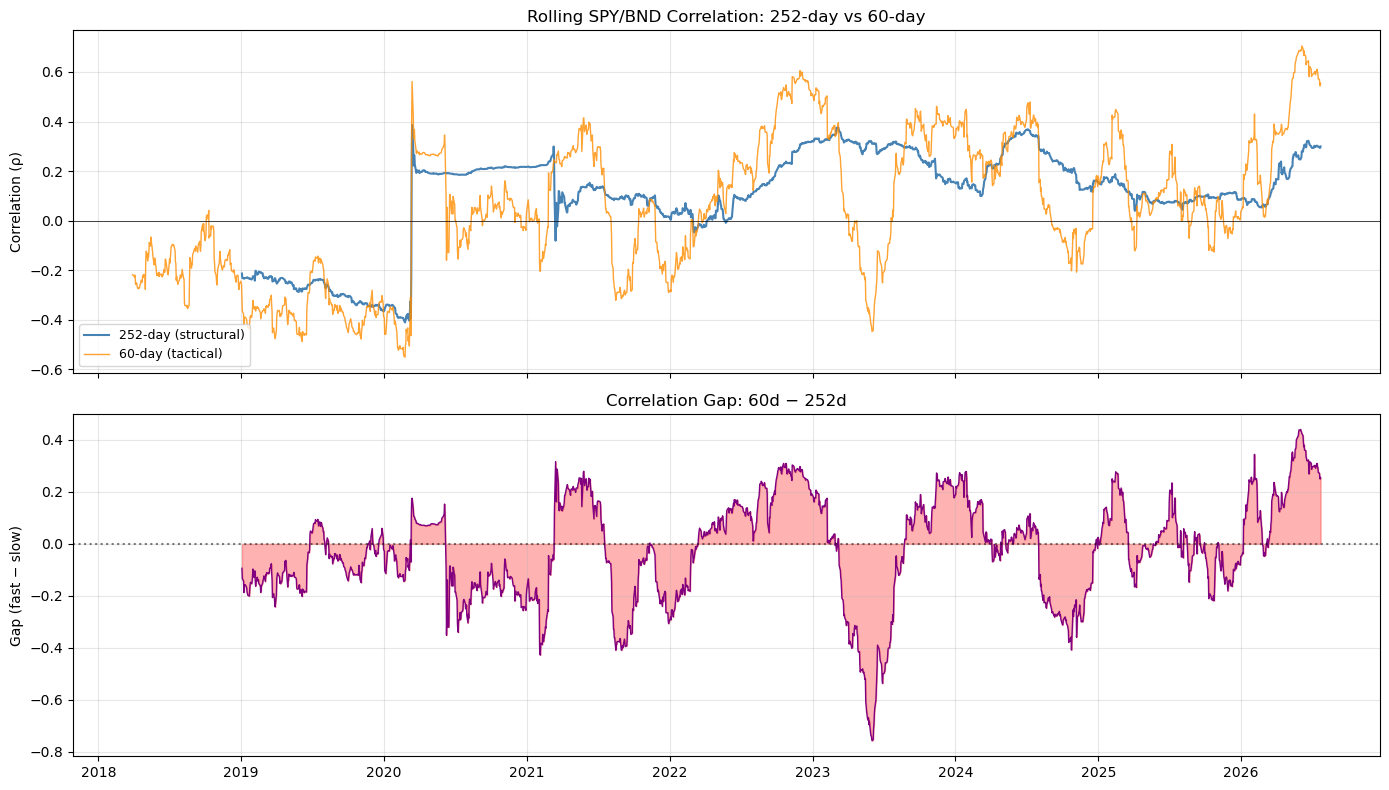

Days with |gap| > 0.2: 603 (31.8% of observations)


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Both correlations
ax = axes[0]
ax.plot(corr_252.index, corr_252, label=f"{CORR_WINDOW_SLOW}-day (structural)",
        color="steelblue", linewidth=1.5)
ax.plot(corr_60.index, corr_60, label=f"{CORR_WINDOW_FAST}-day (tactical)",
        color="darkorange", linewidth=1, alpha=0.8)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.set_ylabel("Correlation (ρ)")
ax.set_title(f"Rolling SPY/BND Correlation: {CORR_WINDOW_SLOW}-day vs {CORR_WINDOW_FAST}-day")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: The gap between fast and slow
ax = axes[1]
# Align indices for the gap
common_idx = corr_252.index.intersection(corr_60.index)
gap = corr_60.loc[common_idx] - corr_252.loc[common_idx]
ax.fill_between(gap.index, 0, gap, alpha=0.3,
                color="purple" if gap.mean() > 0 else "red")
ax.plot(gap.index, gap, color="purple", linewidth=1)
ax.axhline(y=0, color="black", linestyle=":", alpha=0.5)
ax.set_ylabel("Gap (fast − slow)")
ax.set_title(f"Correlation Gap: {CORR_WINDOW_FAST}d − {CORR_WINDOW_SLOW}d")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# Summary stat
diverging = (gap.abs() > 0.2).sum()
print(f"Days with |gap| > 0.2: {diverging} ({diverging/len(gap):.1%} of observations)")

### Why this matters for your VaR

When the 60-day correlation is well below the 252-day, your portfolio VaR is getting a diversification benefit that the slow estimate hasn't fully registered yet — your reported VaR may be *lower* than what current conditions warrant. When the 60-day spikes above the 252-day, the opposite: the diversification you're counting on is already eroding, but your VaR hasn't caught up.

At Spreadex, if you're monitoring a multi-asset book and the fast correlation between two large positions is diverging from the slow, the VaR number you show traders this morning is based on yesterday's correlation regime — not today's.

---

## Part B: The 2022 correlation flip — quantifying the lag

The canonical example: stocks and bonds flipped from negatively correlated to positively correlated during the rate-hiking cycle. How long did the 252-day estimate take to notice?

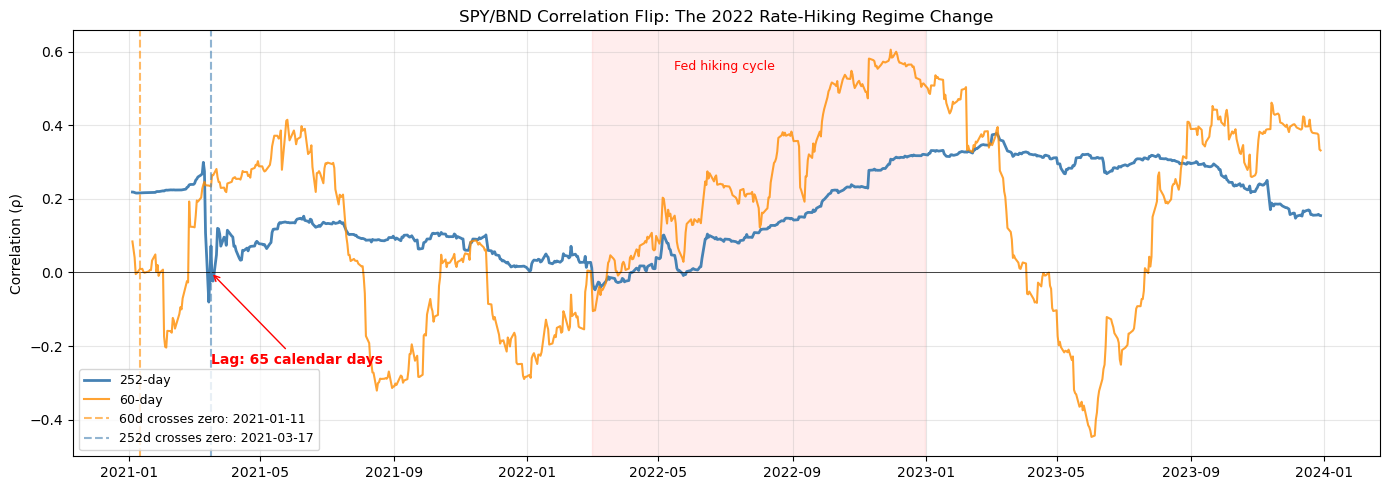

In [6]:
# Zoom into the regime change — align indices first
zoom_start = "2021-01-01"
zoom_end = "2023-12-31"

# Align to common dates (different warm-up periods)
common_zoom_idx = corr_252.index.intersection(corr_60.index)
mask = (common_zoom_idx >= zoom_start) & (common_zoom_idx <= zoom_end)
zoom_idx = common_zoom_idx[mask]
c252_zoom = corr_252.loc[zoom_idx]
c60_zoom = corr_60.loc[zoom_idx]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(c252_zoom.index, c252_zoom, label=f"{CORR_WINDOW_SLOW}-day",
        color="steelblue", linewidth=2)
ax.plot(c60_zoom.index, c60_zoom, label=f"{CORR_WINDOW_FAST}-day",
        color="darkorange", linewidth=1.5, alpha=0.8)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)

# Find when each crossed zero (going up) — use shift-based detection
c252_cross = None
c60_cross = None
c252_prev = c252_zoom.shift(1)
c60_prev = c60_zoom.shift(1)
c252_crossed = (c252_prev < 0) & (c252_zoom >= 0)
c60_crossed = (c60_prev < 0) & (c60_zoom >= 0)
if c252_crossed.any():
    c252_cross = c252_crossed[c252_crossed].index[0]
if c60_crossed.any():
    c60_cross = c60_crossed[c60_crossed].index[0]

if c60_cross:
    ax.axvline(x=c60_cross, color="darkorange", linestyle="--", alpha=0.6,
              label=f"60d crosses zero: {c60_cross.date()}")
if c252_cross:
    ax.axvline(x=c252_cross, color="steelblue", linestyle="--", alpha=0.6,
              label=f"252d crosses zero: {c252_cross.date()}")
    if c60_cross:
        lag_days = (c252_cross - c60_cross).days
        ax.annotate(f"Lag: {lag_days} calendar days",
                    xy=(c252_cross, 0), xytext=(c252_cross, -0.25),
                    arrowprops=dict(arrowstyle="->", color="red"),
                    fontsize=10, color="red", fontweight="bold")

# Shade the rate-hiking period
ax.axvspan(pd.Timestamp("2022-03-01"), pd.Timestamp("2022-12-31"), alpha=0.07, color="red")
ax.annotate("Fed hiking cycle", xy=(pd.Timestamp("2022-07-01"), 0.55),
            fontsize=9, color="red", ha="center")

ax.set_ylabel("Correlation (ρ)")
ax.set_title("SPY/BND Correlation Flip: The 2022 Rate-Hiking Regime Change")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


### Reading the chart

The 60-day correlation crossed zero first — it detected the shift within weeks. The 252-day correlation lagged by months. During that lag period, a risk manager relying on the 252-day estimate still thought stocks and bonds were diversifying each other. They weren't.

**For your VaR:** during those months of lag, your 252-day rolling VaR was computed from a window that was still ~half old-regime data. The portfolio VaR was understating the risk. The naive sum (ρ = +1) was the more honest number.

---

## Part C: The correlation ratio as a regime-change signal

Rather than pick one window, track the ratio. When $\rho_{60} / \rho_{252}$ diverges sharply from 1.0, the fast window is seeing something the slow window hasn't absorbed. This is the same logic as the multi-window VaR divergence you've already built — different windows, same principle.

Ratio capped at ±5: 1 observations
Denominator |ρ₂₅₂| < 0.05: 133 observations


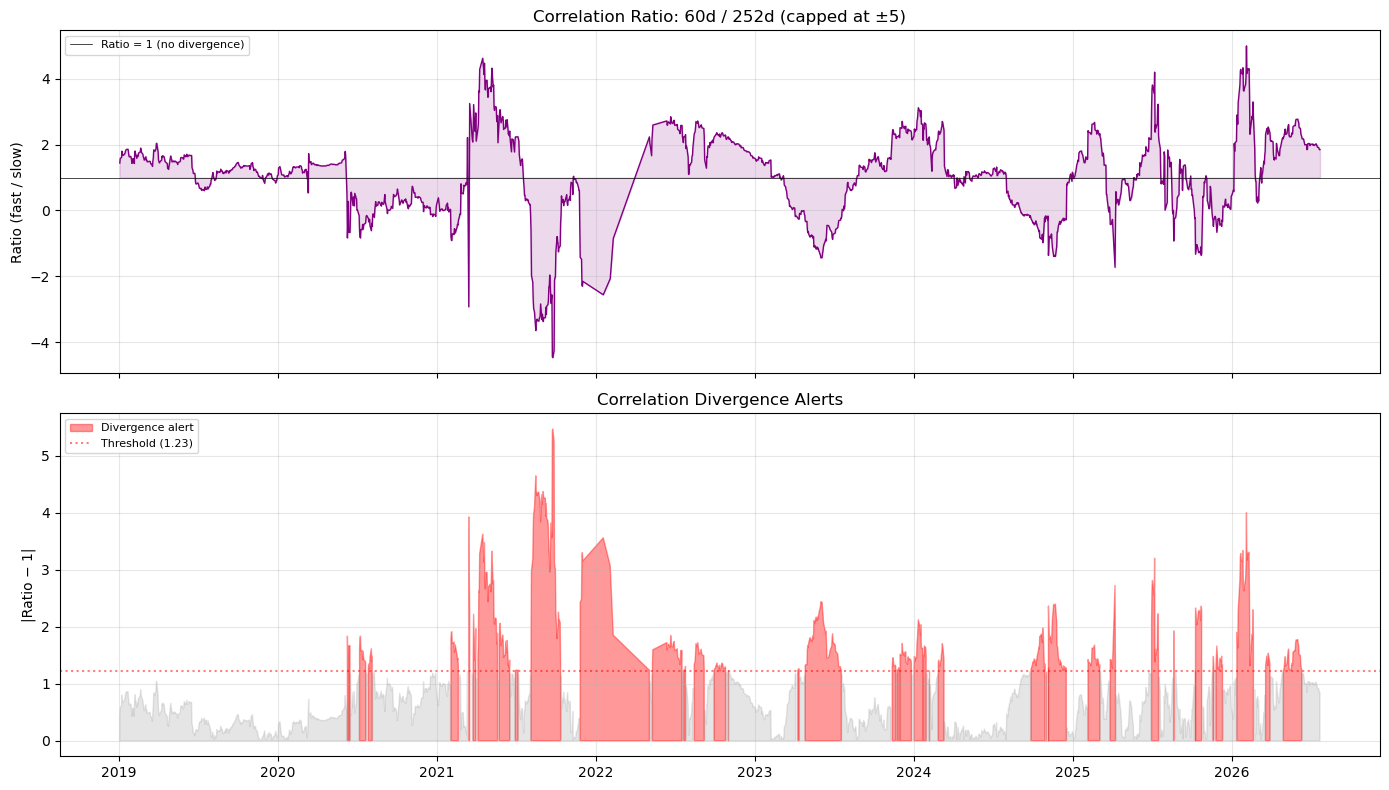


Divergence alerts: 522 days (29.6% of observations)
Latest ratio: 1.85


In [7]:
# Correlation ratio (fast / slow)
# Cap extreme values when denominator (252d ρ) is near zero
common_idx = corr_252.index.intersection(corr_60.index)
ratio_raw = corr_60.loc[common_idx] / corr_252.loc[common_idx]

# Mask where denominator is too close to zero (ratio explodes)
near_zero = corr_252.loc[common_idx].abs() < 0.05
ratio_raw = ratio_raw.where(~near_zero)  # set to NaN where unreliable

# Replace infinities and clip to a reasonable range for plotting
ratio_raw = ratio_raw.replace([np.inf, -np.inf], np.nan)
ratio = ratio_raw.clip(lower=-5, upper=5).dropna()

n_capped = (ratio_raw.abs() > 5).sum()
n_near_zero = near_zero.sum()
print(f"Ratio capped at ±5: {n_capped} observations")
print(f"Denominator |ρ₂₅₂| < 0.05: {n_near_zero} observations")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Correlation ratio (capped)
ax = axes[0]
ax.plot(ratio.index, ratio, color="purple", linewidth=1)
ax.axhline(y=1.0, color="black", linestyle="-", linewidth=0.5, label="Ratio = 1 (no divergence)")
ax.fill_between(ratio.index, 1.0, ratio, alpha=0.15, color="purple")
ax.set_ylabel("Ratio (fast / slow)")
ax.set_title(f"Correlation Ratio: {CORR_WINDOW_FAST}d / {CORR_WINDOW_SLOW}d (capped at ±5)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Flag periods of significant divergence
ax = axes[1]
divergence = (ratio - 1.0).abs()
threshold = divergence.std() * 1.5
alert = divergence > threshold
ax.fill_between(divergence.index, 0, divergence,
                where=alert, color="red", alpha=0.4, label="Divergence alert")
ax.fill_between(divergence.index, 0, divergence,
                where=~alert, color="gray", alpha=0.2)
ax.axhline(y=threshold, color="red", linestyle=":", alpha=0.5,
          label=f"Threshold ({threshold:.2f})")
ax.set_ylabel("|Ratio − 1|")
ax.set_title("Correlation Divergence Alerts")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nDivergence alerts: {alert.sum()} days ({alert.sum()/len(alert):.1%} of observations)")
print(f"Latest ratio: {ratio.iloc[-1]:.2f}")


### Interpreting the ratio

- **Ratio ≈ 1:** Fast and slow agree. The correlation regime is stable. Your VaR assumptions are likely current.
- **Ratio ≫ 1 (fast well above slow):** Correlation is *rising*. Assets are moving more together than your long-run estimate suggests. Your VaR is understating risk — the naive sum is closer to reality.
- **Ratio ≪ 1 (fast well below slow):** Correlation is *falling*. You're getting more diversification than the long-run estimate credits. Your VaR is conservative. (Rare as a problem, but worth noting — it means your risk budget may be too tight.)
- **Ratio flips sign (fast and slow disagree on direction):** Maximum divergence. The regime has fundamentally changed. This is the 2022 scenario.

---

## Part D: Correlation and the diversification benefit — the full picture

Correlation is the *cause*. The diversification benefit is the *symptom*. When we overlay them, the relationship becomes visible — and the leading-indicator property of the benefit (from Notebook 12) gets its explanation.

In [8]:
# Recompute rolling VaR and benefit (from Notebook 12 logic)
rolling_benefit = None  # placeholder — computed below

# Rolling VaR for each individual asset and portfolio
rv_spy = rolling_var(aligned[TICKERS[0]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_bnd = rolling_var(aligned[TICKERS[1]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_port = rolling_var(portfolio_returns, window=VAR_WINDOW, confidence=CONFIDENCE)

# Rolling naive sum and benefit
rolling_naive = WEIGHTS[0] * rv_spy["VaR"] + WEIGHTS[1] * rv_bnd["VaR"]
rolling_benefit = (rolling_naive - rv_port["VaR"]) / rolling_naive

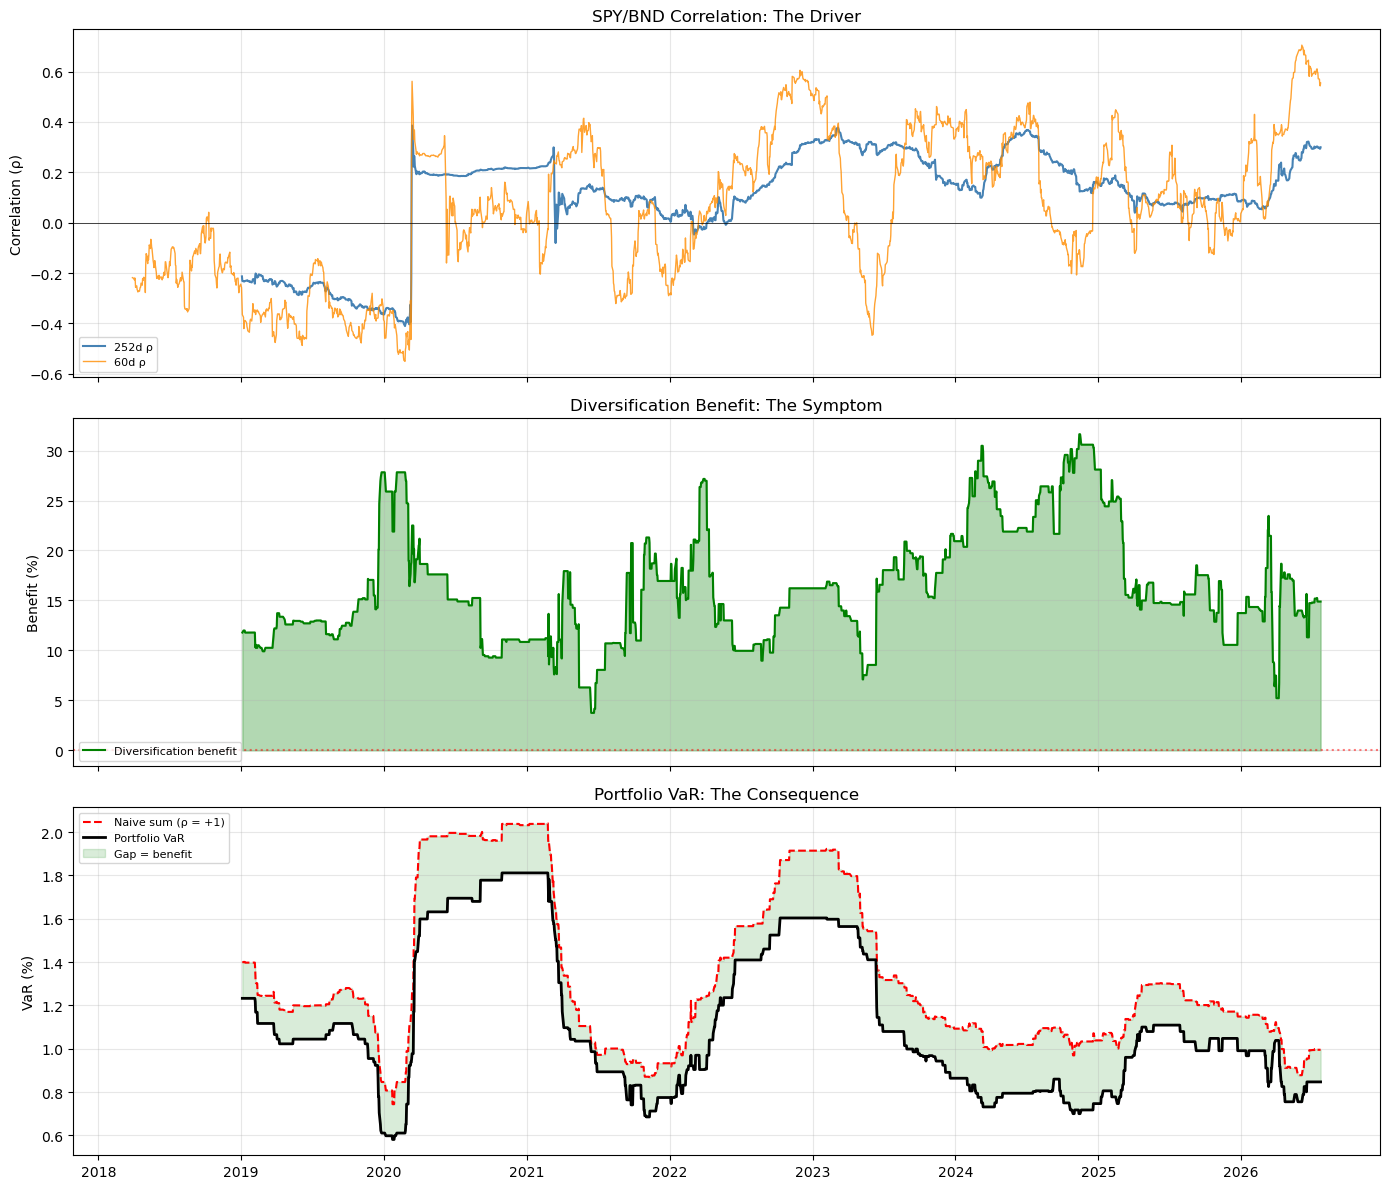

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Correlation (inverted — higher = less diversification)
ax = axes[0]
ax.plot(corr_252.index, corr_252, label=f"{CORR_WINDOW_SLOW}d ρ",
        color="steelblue", linewidth=1.5)
ax.plot(corr_60.index, corr_60, label=f"{CORR_WINDOW_FAST}d ρ",
        color="darkorange", linewidth=1, alpha=0.8)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.set_ylabel("Correlation (ρ)")
ax.set_title("SPY/BND Correlation: The Driver")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Diversification benefit (inverted relationship to correlation)
ax = axes[1]
ax.fill_between(rolling_benefit.index, 0, rolling_benefit * 100,
                alpha=0.3, color="green")
ax.plot(rolling_benefit.index, rolling_benefit * 100,
        color="green", linewidth=1.5, label="Diversification benefit")
ax.axhline(y=0, color="red", linestyle=":", alpha=0.5)
ax.set_ylabel("Benefit (%)")
ax.set_title("Diversification Benefit: The Symptom")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Portfolio VaR vs naive sum
ax = axes[2]
ax.plot(rolling_naive.index, rolling_naive * 100,
        label="Naive sum (ρ = +1)", color="red", linestyle="--", linewidth=1.5)
ax.plot(rv_port.index, rv_port["VaR"] * 100,
        label="Portfolio VaR", color="black", linewidth=2)
ax.fill_between(rv_port.index, rv_port["VaR"] * 100, rolling_naive * 100,
                alpha=0.15, color="green", label="Gap = benefit")
ax.set_ylabel("VaR (%)")
ax.set_title("Portfolio VaR: The Consequence")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Reading the three panels together

Top to bottom: **cause → symptom → consequence.**

When correlation rises (panel 1), the diversification benefit falls (panel 2), and the gap between portfolio VaR and the naive sum narrows (panel 3). When the gap closes completely, your portfolio is a concentrated bet regardless of how many tickers you hold.

This is the full story that VaR alone misses. A single VaR number — 1.10% — doesn't tell you whether it's backed by genuine diversification or just a lucky correlation regime.

---

## Part E: What this means in practice — your context

### At a spread betting firm (Spreadex)

You're monitoring a multi-asset book. A client has a large SPY position and a large BND position. Your risk system computes VaR on the combined position and reports it to traders. If the SPY/BND correlation has shifted but your VaR window hasn't absorbed it yet, the VaR number you show this morning understates the risk.

The correlation ratio gives you an **independent check** on your VaR estimate. When $\rho_{60} / \rho_{252}$ diverges sharply, you know the VaR number is running on stale correlation assumptions. You can flag this to traders: *"VaR is 1.10%, but correlation is rising — the naive sum of 1.27% may be more realistic if the trend continues."*

### Building VaR models for institutional investors (FINBOURNE context)

An asset manager runs a 60/40 portfolio and reports 95% VaR to their risk committee. They use a 252-day window because "that's the standard." In 2022, that standard gave them a VaR number that was months out of date. If you had shown them the correlation ratio alongside the VaR, they would have seen the divergence and had time to reduce risk before the losses materialised.

The feature isn't complicated — two rolling correlations and a ratio — but the *decision it enables* ("should I trust my VaR right now?") is high-value.

### For your own development

This is the pattern that separates a VaR calculator from a risk monitoring system. A calculator gives you a number. A monitoring system tells you whether to trust it. The correlation ratio, the diversification benefit, the multi-window VaR divergence — these are all instances of the same principle: **track the disagreement between methods, not just the methods themselves.**

In [10]:
# Quick summary: correlation and VaR at key dates
key_dates = ["2020-03-23", "2021-06-14", "2022-10-12", "2024-11-13"]
key_labels = ["COVID low", "Benefit min", "2022 CPI peak", "Benefit max"]

print(f"{'Date':<12} {'Label':<16} {'252d ρ':>8} {'60d ρ':>8} {'Ratio':>8} {'Benefit':>9}")
print("-" * 66)
for date, label in zip(key_dates, key_labels):
    dt = pd.Timestamp(date)
    rho252 = corr_252.loc[corr_252.index >= dt].iloc[0] if any(corr_252.index >= dt) else np.nan
    rho60 = corr_60.loc[corr_60.index >= dt].iloc[0] if any(corr_60.index >= dt) else np.nan
    rat = rho60 / rho252 if abs(rho252) > 0.01 else np.nan
    ben = rolling_benefit.loc[rolling_benefit.index >= dt].iloc[0] if any(rolling_benefit.index >= dt) else np.nan
    print(f"{date:<12} {label:<16} {rho252:>8.3f} {rho60:>8.3f} {rat:>8.2f} {ben:>8.1%}")

print(f"\n{'Latest':<12} {'':<16} {corr_252.iloc[-1]:>8.3f} {corr_60.iloc[-1]:>8.3f} {ratio.iloc[-1]:>8.2f} {rolling_benefit.iloc[-1]:>8.1%}")

Date         Label              252d ρ    60d ρ    Ratio   Benefit
------------------------------------------------------------------
2020-03-23   COVID low           0.201    0.288     1.44    19.1%
2021-06-14   Benefit min         0.139    0.322     2.32     3.8%
2022-10-12   2022 CPI peak       0.224    0.520     2.32    14.3%
2024-11-13   Benefit max         0.150   -0.107    -0.71    31.6%

Latest                           0.299    0.555     1.85    14.9%


---

## Key takeaways

1. **Correlation is the driver; the diversification benefit is the symptom.** When ρ rises, the benefit falls. When ρ crosses zero and goes positive, the benefit can collapse entirely.
2. **The 252-day correlation lags reality by months.** During the 2022 regime change, the 60-day estimate crossed zero weeks ahead of the 252-day. Anyone relying on the 252-day number was flying blind.
3. **The correlation ratio ($\rho_{60} / \rho_{252}$) is your early warning.** When it diverges from 1.0, the regime is shifting. When it flips sign, the regime has changed. This is the correlation equivalent of multi-window VaR divergence.
4. **For historical VaR, stale correlation = stale VaR.** Your VaR window takes time to absorb the new correlation regime — same lag you've studied in single-asset VaR, but now the mechanism is the pairwise relationship rather than volatility alone.
5. **The naive sum is your stress test when correlation is rising.** When $\rho_{60} \gg \rho_{252}$, the portfolio VaR is understating risk — use the naive sum as your forward-looking estimate until the window catches up.
6. **This is the same principle across your entire toolkit.** Multi-window VaR divergence, decay-weighted vs equal-weighted, correlation ratio — they all work by tracking disagreement between methods. A single number can be wrong. Disagreement between numbers is the signal.